# Car Price Prediction Using Machine Learning

### Objective
To build a machine learning regression model that predicts the selling price
of used cars based on features such as present price, year, driven kilometers,
fuel type, selling type, transmission, and owner information.

### Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv("car data.csv")

# Display first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 301
Number of columns: 9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


In [8]:
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


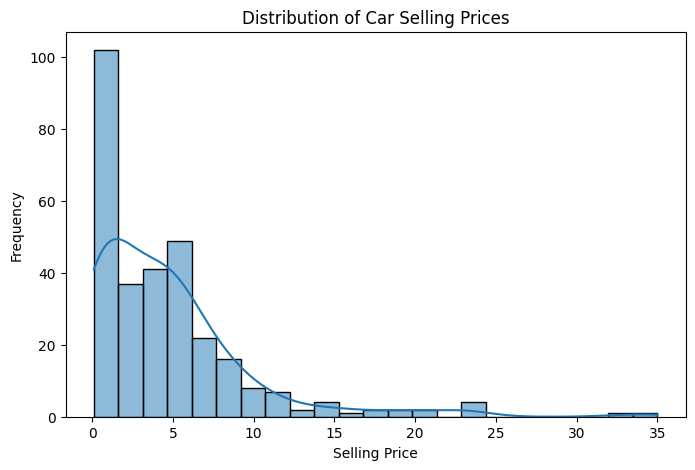

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

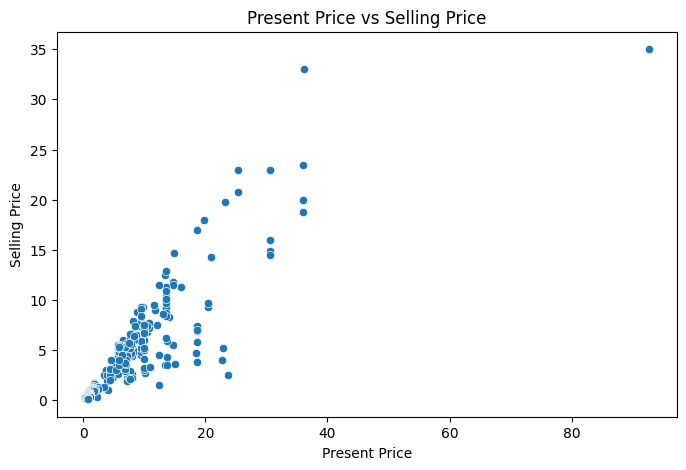

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

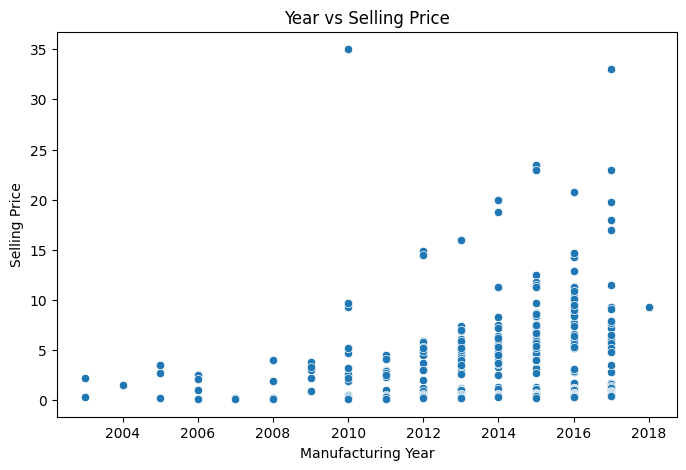

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Year",
    y="Selling_Price"
)

plt.title("Year vs Selling Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Selling Price")

plt.show()

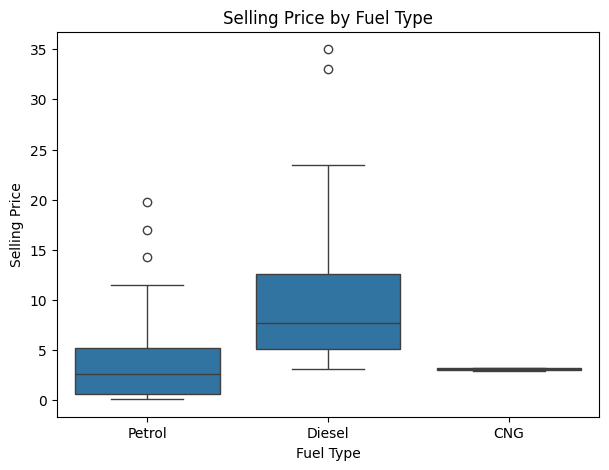

In [12]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

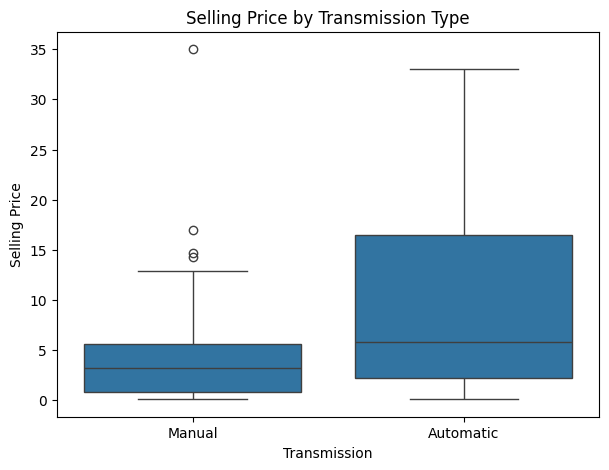

In [13]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Transmission",
    y="Selling_Price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

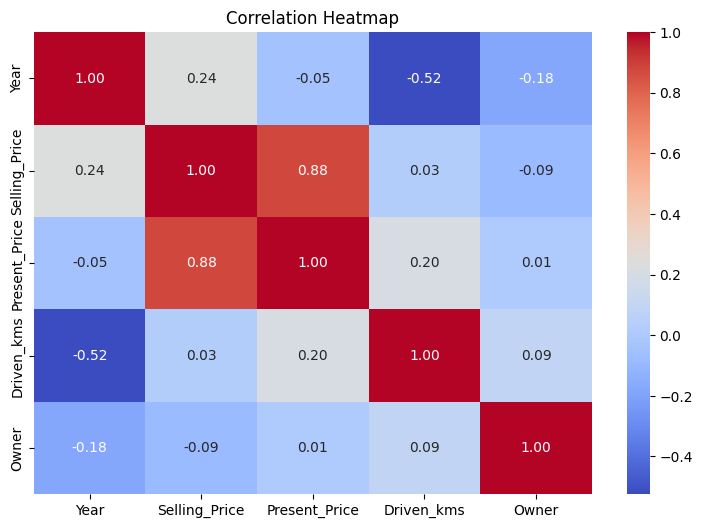

In [14]:
plt.figure(figsize=(9, 6))

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [15]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Selling_Price")

Features:
['Car_Name', 'Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Target:
Selling_Price


In [16]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Year', 'Present_Price', 'Driven_kms', 'Owner']

Categorical Features:
['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 240
Testing samples: 61


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


In [19]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

print("Linear Regression model pipeline created!")

Linear Regression model pipeline created!


In [20]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [21]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[ 1.51256206  9.5888037   5.568846   -0.40946744  8.55896256  6.88892357
  1.47636881  0.27624874  0.98016002  6.68924072]


In [22]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Model Evaluation
------------------------
Mean Absolute Error (MAE): 1.10
Root Mean Squared Error (RMSE): 1.51
R² Score: 0.90


In [23]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,0.35,1.512562
1,10.11,9.588804
2,4.95,5.568846
3,0.15,-0.409467
4,6.95,8.558963
5,7.45,6.888924
6,1.10,1.476369
7,0.50,0.276249
8,0.45,0.980160
9,6.00,6.689241


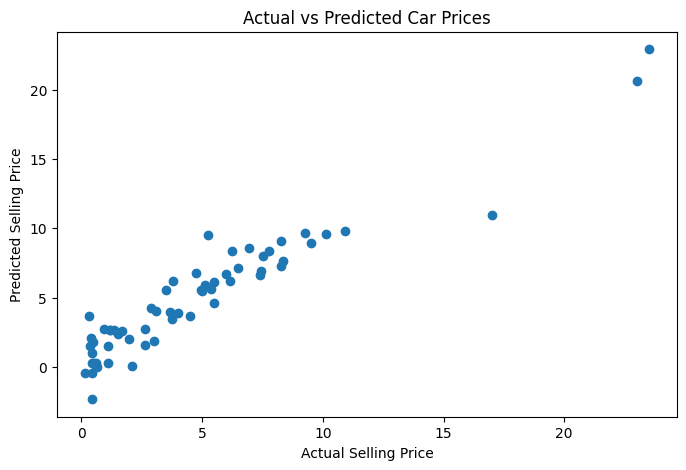

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

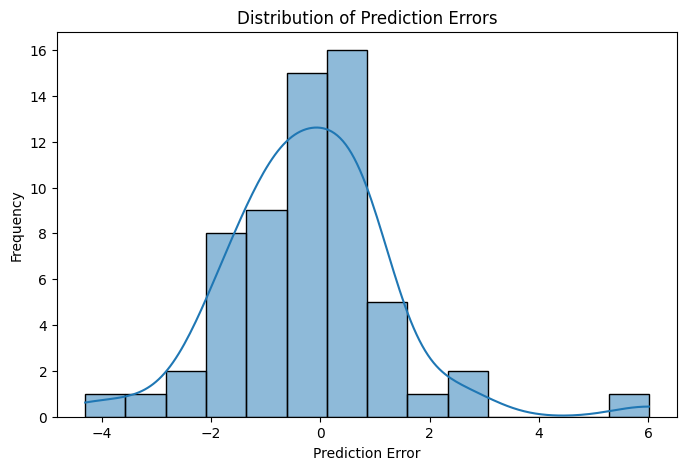

In [25]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.histplot(errors, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [26]:
new_car = pd.DataFrame({
    "Car_Name": ["ritz"],
    "Year": [2015],
    "Present_Price": [5.59],
    "Driven_kms": [27000],
    "Fuel_Type": ["Petrol"],
    "Selling_type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0]
})

predicted_price = model.predict(new_car)

print(f"Predicted Selling Price: {predicted_price[0]:.2f}")

Predicted Selling Price: 4.39


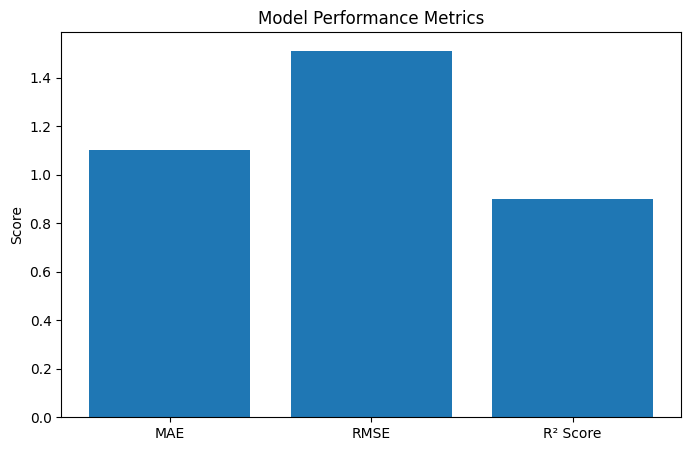

In [27]:
metrics = ["MAE", "RMSE", "R² Score"]
values = [mae, rmse, r2]

plt.figure(figsize=(8, 5))

plt.bar(metrics, values)

plt.title("Model Performance Metrics")
plt.ylabel("Score")

plt.show()

## Conclusion

The Car Price Prediction project successfully demonstrates a complete machine
learning regression workflow. The dataset was explored, cleaned, visualized,
and preprocessed before training a Linear Regression model.

The model was evaluated using MAE, RMSE, and R² Score and was also used to
predict the selling price of a new car based on its features.